# Task 7.1 — CW ODMR fits

Fits Lorentzian dips to the two ODMR sweeps:
- `cwODMR.csv` — **zero-field**, single dip → zero-field splitting *D*, linewidth
- `cwODMR_B0.csv` — **with B-field**, multiple dips → Zeeman splittings → |B₀|

**Sign convention:** the MW is AM-chopped at 10 kHz, so the lock-in reads
$V_\text{lockin} \propto (I_\text{off} - I_\text{res})$. Resonances appear as **negative dips** on a baseline near 0. We fit
$$
S(f) = c - \sum_i A_i \frac{(\gamma_i/2)^2}{(f - f_i)^2 + (\gamma_i/2)^2}
$$
with $A_i > 0$ so the curve dips at $f = f_i$.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

GAMMA_E_HZ_PER_T = 28.024e9  # NV electron gyromagnetic ratio, Hz/T

NO_B   = r"ALEXQUADRAT\20260122_140241_cwODMR\setCounter_['0']\cwODMR.csv"
WITH_B = r"ALEXQUADRAT\20260122_142107_cwODMR\setCounter_['0']\cwODMR_B0.csv"

## Helpers — loader, model, peak guesser

In [2]:
def load(path):
    df = pd.read_csv(path, sep=";")
    df.columns = [c.strip() for c in df.columns]
    return df["setFrequency"].to_numpy(), df["readOutput"].to_numpy()


def lorentzian(f, f0, gamma, A):
    return A * (gamma / 2) ** 2 / ((f - f0) ** 2 + (gamma / 2) ** 2)


def model_n(f, *params):
    """params: [c, f1, gamma1, A1, f2, gamma2, A2, ...] returning c - sum_i L_i."""
    c = params[0]
    out = np.full_like(f, c, dtype=float)
    for i in range((len(params) - 1) // 3):
        f0, g, A = params[1 + 3 * i : 4 + 3 * i]
        out -= lorentzian(f, f0, g, A)
    return out

In [3]:
def fit_dips(f, V, peak_guesses, gamma_guess=5e6):
    """Fit N negative Lorentzians at the guessed centers."""
    c0 = np.median(V[(V > np.percentile(V, 60))])  # baseline ~ top of signal
    p0 = [c0]
    lo = [-np.inf]
    hi = [np.inf]
    span = f.max() - f.min()
    for fg in peak_guesses:
        A0 = c0 - V[np.argmin(np.abs(f - fg))]
        p0 += [fg, gamma_guess, max(A0, 1e-9)]
        lo += [fg - 0.05 * span, 5e5, 0]
        hi += [fg + 0.05 * span, span / 2, np.inf]
    popt, pcov = curve_fit(model_n, f, V, p0=p0, bounds=(lo, hi), maxfev=20000)
    perr = np.sqrt(np.diag(pcov))
    return popt, perr


def guess_peaks(f, V, n_expect=None):
    """Use find_peaks on -V to locate dips."""
    y = -(V - np.median(V))
    prom = 0.15 * y.max()
    idx, _ = find_peaks(y, prominence=prom, distance=3)
    if n_expect is not None and len(idx) > n_expect:
        proms = -V[idx]
        idx = idx[np.argsort(proms)[-n_expect:]]
        idx = np.sort(idx)
    return f[idx]

## Zero-field ODMR — extract *D* and linewidth

In [4]:
f0_arr, V0_arr = load(NO_B)
guesses = guess_peaks(f0_arr, V0_arr)
print(f"detected {len(guesses)} dip(s) at {[round(f/1e9, 4) for f in guesses]} GHz")

popt0, perr0 = fit_dips(f0_arr, V0_arr, guesses)
c0, D, gamma_D, A_D = popt0

print(f"D (zero-field splitting) = {D/1e9:.4f} +/- {perr0[1]/1e6:.3f} GHz ({D/1e6:.2f} MHz)")
print(f"FWHM = {gamma_D/1e6:.2f} +/- {perr0[2]/1e6:.2f} MHz")
print(f"dip amplitude (lock-in) = {A_D*1e6:.2f} uV   baseline c = {c0*1e6:.2f} uV")
print(f"relative lock-in dip depth A/|min(V)| = {A_D/abs(V0_arr.min()):.2f}")

detected 1 dip(s) at [2.871] GHz
D (zero-field splitting) = 2.8696 +/- 0.058 GHz (2869.60 MHz)
FWHM = 9.97 +/- 0.19 MHz
dip amplitude (lock-in) = 15.08 uV   baseline c = 0.19 uV
relative lock-in dip depth A/|min(V)| = 1.09


## With B-field — multi-Lorentzian fit

The wide sweep shows several Zeeman-split dips. `find_peaks` locates them; if the central feature looks like an unresolved doublet (3 peaks found instead of 4), we add a 4th seed and re-split.

In [5]:
fB, VB = load(WITH_B)
guesses_B = guess_peaks(fB, VB)
print(f"detected {len(guesses_B)} dip(s) at {[round(f/1e9, 4) for f in guesses_B]} GHz")

if len(guesses_B) == 3:
    central = guesses_B[len(guesses_B) // 2]
    guesses_B = np.sort(np.append(guesses_B, central + 6e6))
    guesses_B[1] -= 3e6
    guesses_B[2] += 3e6
    print(f"  added split for central doublet -> seeds {[round(f/1e9, 4) for f in guesses_B]} GHz")

poptB, perrB = fit_dips(fB, VB, guesses_B, gamma_guess=4e6)
cB = poptB[0]
centers = poptB[1::3]
widths  = poptB[2::3]
amps    = poptB[3::3]

print(f"\nbaseline cB = {cB*1e6:.2f} uV")
for i, (fc, g, A) in enumerate(zip(centers, widths, amps)):
    print(f"  dip {i+1}: f = {fc/1e9:.4f} GHz   FWHM = {g/1e6:.2f} MHz   amp = {A*1e6:.2f} uV")

detected 4 dip(s) at [2.783, 2.873, 2.879, 2.963] GHz

baseline cB = -0.25 uV
  dip 1: f = 2.7822 GHz   FWHM = 10.37 MHz   amp = 4.51 uV
  dip 2: f = 2.8726 GHz   FWHM = 6.81 MHz   amp = 5.09 uV
  dip 3: f = 2.8795 GHz   FWHM = 6.22 MHz   amp = 5.35 uV
  dip 4: f = 2.9619 GHz   FWHM = 7.90 MHz   amp = 3.92 uV


## Zeeman splittings → magnitude of B₀

Pair the dips symmetrically about the mean. If $B \parallel [111]$:
- the **outer** pair is from the NV oriented along $B$ (on-axis), split by $2\gamma_e B$
- the **inner** pair is from the three off-axis NVs at the tetrahedral angle (109.47°), projection $B/3$, split by $2\gamma_e B/3$

Both should give the same $|B|$ — a consistency check on the [111] alignment guess.

In [6]:
centers_sorted = np.sort(centers)
n = len(centers_sorted)
D_est = centers_sorted.mean()
pairs = []
for i in range(n // 2):
    lo = centers_sorted[i]
    hi = centers_sorted[-1 - i]
    delta = hi - lo
    f_proj = delta / 2 / GAMMA_E_HZ_PER_T  # |B_parallel| for that NV class (T)
    pairs.append((lo, hi, delta, f_proj))
    print(f"Zeeman pair: ({lo/1e9:.4f}, {hi/1e9:.4f}) GHz   split = {delta/1e6:.2f} MHz   B_proj = {f_proj*1e3:.3f} mT")

if len(pairs) >= 2:
    delta_outer = pairs[0][2]
    delta_inner = pairs[1][2]
    B_from_outer = delta_outer / (2 * GAMMA_E_HZ_PER_T)
    B_from_inner = delta_inner / (2 * GAMMA_E_HZ_PER_T) * 3   # if [111]
    print("\nAssuming B || [111]:")
    print(f"  |B| from outer pair (on-axis NV)   = {B_from_outer*1e3:.3f} mT")
    print(f"  |B| from inner pair (off-axis x3)  = {B_from_inner*1e3:.3f} mT")
    print(f"  consistency: {(B_from_inner-B_from_outer)/B_from_outer*100:+.1f} %")

Zeeman pair: (2.7822, 2.9619) GHz   split = 179.64 MHz   B_proj = 3.205 mT
Zeeman pair: (2.8726, 2.8795) GHz   split = 6.89 MHz   B_proj = 0.123 mT

Assuming B || [111]:
  |B| from outer pair (on-axis NV)   = 3.205 mT
  |B| from inner pair (off-axis x3)  = 0.369 mT
  consistency: -88.5 %


## Plot the fits

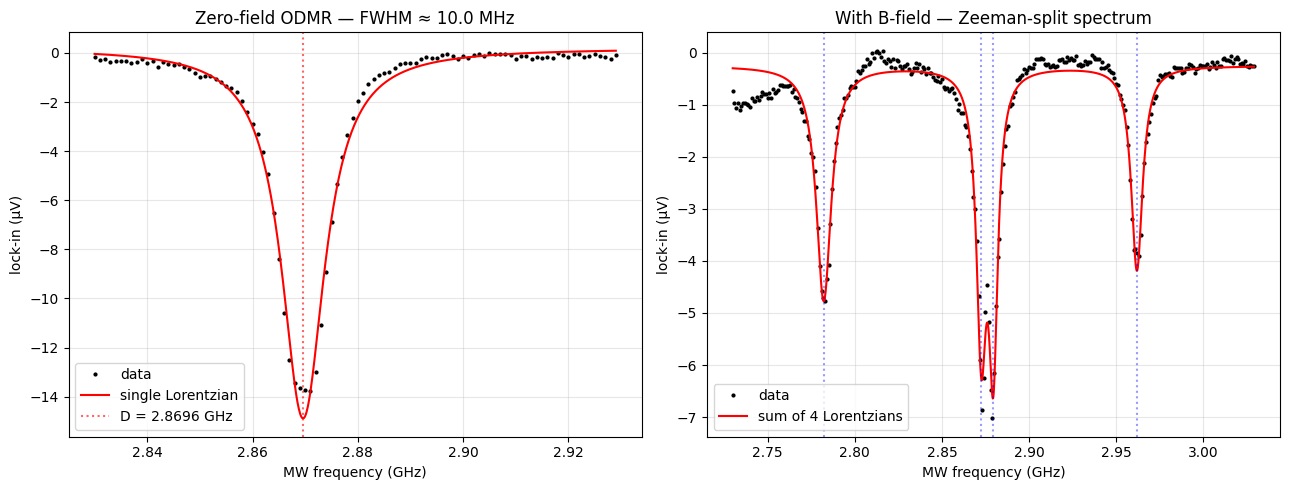

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(f0_arr / 1e9, V0_arr * 1e6, "k.", ms=4, label="data")
f_dense = np.linspace(f0_arr.min(), f0_arr.max(), 800)
ax.plot(f_dense / 1e9, model_n(f_dense, *popt0) * 1e6, "r-", lw=1.5, label="single Lorentzian")
ax.axvline(D / 1e9, color="r", ls=":", alpha=0.6, label=f"D = {D/1e9:.4f} GHz")
ax.set_xlabel("MW frequency (GHz)")
ax.set_ylabel("lock-in (µV)")
ax.set_title(f"Zero-field ODMR — FWHM ≈ {gamma_D/1e6:.1f} MHz")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(fB / 1e9, VB * 1e6, "k.", ms=4, label="data")
f_dense = np.linspace(fB.min(), fB.max(), 1500)
ax.plot(f_dense / 1e9, model_n(f_dense, *poptB) * 1e6, "r-", lw=1.5,
        label=f"sum of {len(centers)} Lorentzians")
for fc in centers:
    ax.axvline(fc / 1e9, color="b", ls=":", alpha=0.4)
ax.set_xlabel("MW frequency (GHz)")
ax.set_ylabel("lock-in (µV)")
ax.set_title("With B-field — Zeeman-split spectrum")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig("odmr_fits.png", dpi=140)
plt.show()